# Unsupervised floe metrics

In order to determine the quality of a segmentation result we need to know what properties a "good" result has. 
* Homogeneity across spectral bands

In [1]:
using Pkg
Pkg.activate("calval")
Pkg.update(; name="IceFloeTracker", rev="main")
using IceFloeTracker
using Images
using Random
using DataFrames
using Plots
using StatsBase

dataset = Watkins2026Dataset(ref="v0.1") # [6, 13, 61, 25, 121, 150]
case = filter(f -> f.case_number in [6, 11, 63, 111, 138, 166]  && f.satellite=="aqua", dataset)

  Activating project at `~/Documents/research/calval_tgrs/notebooks/calval`
    Updating registry at `~/.julia/registries/General.toml`
    Updating git-repo `https://github.com/WilhelmusLab/IceFloeTracker.jl.git`
    Updating `~/Documents/research/calval_tgrs/notebooks/calval/Project.toml`
  [04643c7a] ~ IceFloeTracker v1.0.0 `https://github.com/WilhelmusLab/IceFloeTracker.jl.git#main` ⇒ v1.0.0 `https://github.com/WilhelmusLab/IceFloeTracker.jl.git#main`
    Updating `~/Documents/research/calval_tgrs/notebooks/calval/Manifest.toml`
  [04643c7a] ~ IceFloeTracker v1.0.0 `https://github.com/WilhelmusLab/IceFloeTracker.jl.git#main` ⇒ v1.0.0 `https://github.com/WilhelmusLab/IceFloeTracker.jl.git#main`
Precompiling packages...
  12405.2 ms  ✓ IceFloeTracker
  1 dependency successfully precompiled in 15 seconds. 510 already precompiled.
        Info We haven't cleaned this depot up for a bit, running Pkg.gc()...
      Active manifest files: 12 found
      Active artifact files: 216 found
   

Dataset(GitHubLoader("https://github.com/danielmwatkins/ice-floe-validation-dataset/", "v0.1", "/tmp/Watkins2026"), 6×30 DataFrame
 Row │        case_number  region         start_date  center_lon  center_lat   ⋯
     │ Int64  Int64        String         Dates.Date  Float64     Float64      ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │    11            6  baffin_bay     2022-05-30    -73.3612     75.2608   ⋯
   2 │    20           11  baffin_bay     2011-07-02    -70.7347     72.3303
   3 │   124           63  beaufort_sea   2007-07-11   -128.157      75.5467
   4 │   220          111  greenland_sea  2012-06-23    -14.226      78.0885
   5 │   274          138  hudson_bay     2020-05-09    -83.9204     62.769    ⋯
   6 │   330          166  laptev_sea     2016-09-04    136.931      79.7507
                                                              24 columns omitted)

In [10]:
tc_imgs = modis_truecolor.(case)
fc_imgs = modis_falsecolor.(case)
labeled_floes = validated_labeled_floes.(case)
floes = validated_binary_floes.(case);

## Measures
1. Spectral angle (pixel comparison)
$$\alpha = \cos^{-1} \left(
    \frac{\mathbf{a} \cdot \mathbf{b}}{\|a\|_2 \|b\|_2} 
     \right)
    $$ This would scale as $n^2$ for computation, since it needs to be calculated for each pair of pixels in a segment. This form is compact and nice, the same equation appears in Yang et al. 2014. We can get the segment indices easily and then apply the function to an array. This function can be used while growing a segment, since the change in spectral angle should have a maximum right as you reach an object boundary.
2. Segment variance
3. Contrast along boundaries (Vcp, Vest, Zeb)

## Concepts
See Zhang et al. 2008, Haralick and Shapiro also. Characteristic Criteria: uniformity, homogeneiety, significant difference to nearby shapes. Semantic Criteria: based on information known about the objects under consideration, such as shape. 


In [ ]:
# define segment_var

In [9]:
# img needs to be 2d
function segment_var(segments, img)
    labels = keys(segment_mean(segments))
    indices = component_indices(labels_map(segments))
    return Dict(l => var(img[indices[l]]) for l in labels)
end

segment_var (generic function with 1 method)

In [11]:
labeled_floes[1]

Segmented Image with:
  labels map: 400×400 Matrix{Int64}
  number of labels: 166

In [32]:
variance_b1 = segment_var(labeled_floes[1], red.(fc_imgs[1]));
variance_b2 = segment_var(labeled_floes[1], blue.(fc_imgs[1]));

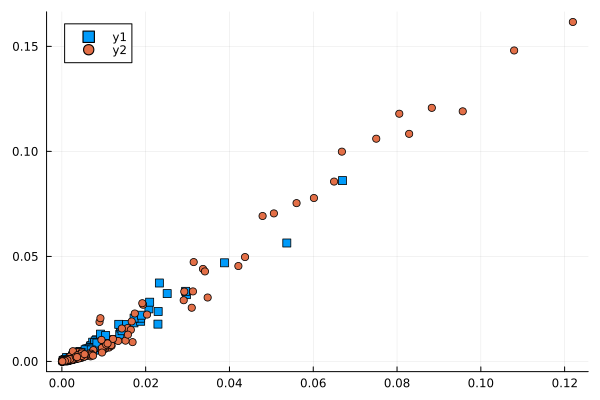

In [36]:
variance_b1 = segment_var(labeled_floes[1], red.(tc_imgs[1]));
variance_b2 = segment_var(labeled_floes[1], blue.(fc_imgs[1]));
labels = keys(variance_b1)
scatter(
    [variance_b1[l] for l in labels],
    [variance_b2[l] for l in labels], marker=:square)

# mismatch
variance_b1 = segment_var(labeled_floes[1], red.(tc_imgs[5]));
variance_b2 = segment_var(labeled_floes[1], blue.(fc_imgs[5]));
labels = keys(variance_b1)

scatter!(
    [variance_b1[l] for l in labels],
    [variance_b2[l] for l in labels], marker=:circle)

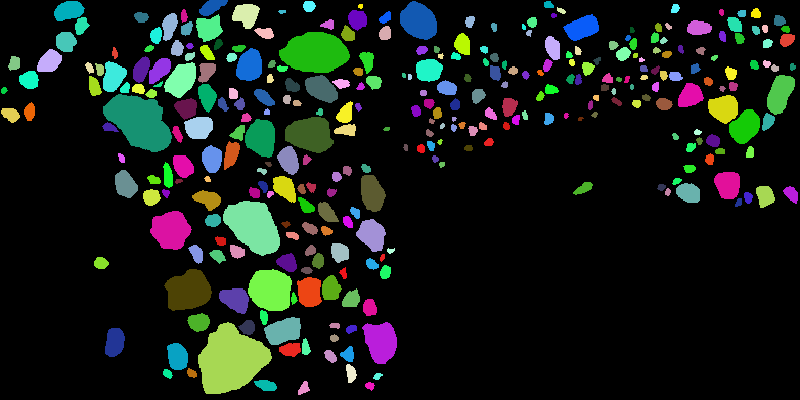

In [34]:
mosaicview(
    view_seg_random(labeled_floes[1]),
    view_seg_random(labeled_floes[5]), nrow=1)
